## Atelier Seaborn 

### Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. 
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer 
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se 
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données.

### Structure du projet
2) Stockage du fichier fourni mesures_capteurs.csv dans le sous-dossier data 
3) Création le notebook atelier_seaborn_iot.ipynb 
4) Installation et importation seaborn, matplotlib, pandas, numpy 
5) Importation mesures_capteurs.csv dans le dataframe df 
6) Vérification le contenu du dataframe df 

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Importation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importation dataframe
df = pd.read_csv(r'C:\Users\cissc\OneDrive\Documents\P1IA_ODC\atelier_pandas\data\mesures_capteurs.csv')
# On ajoute un 'r' devant les guillemets pour éviter les erreurs de caractères)

In [5]:
# le contenu du dataframe df 
df

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
...,...,...,...,...,...,...,...,...,...
600,M0072,2026-01-07 23:00:00,C012,B004,23.67,60.28,1015.11,282.36,OK
601,M0107,2026-01-09 10:00:00,C011,B004,24.34,61.42,1019.43,357.43,OK
602,M0271,2026-01-16 06:00:00,C007,B003,23.73,63.49,1016.46,152.79,OK
603,M0436,2026-01-23 03:00:00,C004,B002,24.83,79.77,1017.05,170.97,OK


In [6]:
df.columns

Index(['id_mesure', 'date_heure', 'id_capteur', 'batiment', 'temperature',
       'humidite', 'pression', 'consommation', 'etat'],
      dtype='str')

#### Partie 1 – Distribution d'une variable avec histplot() 

##### 1) Affichage de la distribution des températures 

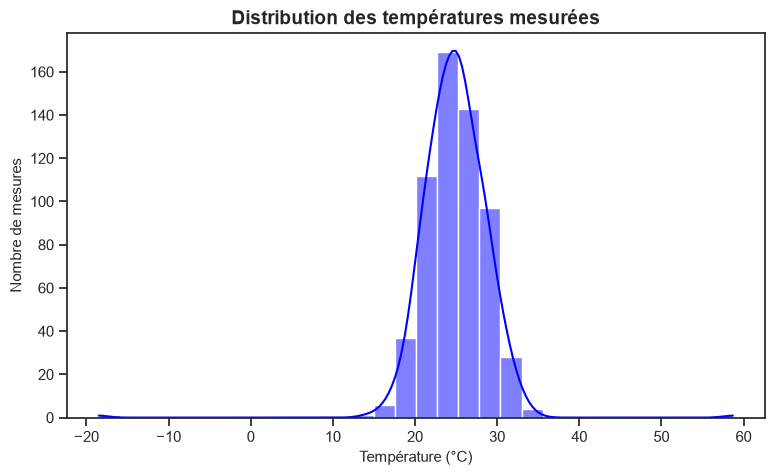

In [7]:
sns.set_theme(style="ticks") # thème visuel pour un rendu propre

plt.figure(figsize=(9, 5))  # l'histogramme avec la courbe de densité (KDE)
sns.histplot(data=df, x="temperature", kde=True, color="blue", bins=30)

# titres et labels
plt.title("Distribution des températures mesurées", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Nombre de mesures", fontsize=11)

plt.show()


2) Autour de quelle valeur les températures sont concentrées ? 

Les températures sont concentrés autour de 25 

3) La distribution semble-t-elle symétrique ? 

Oui la distribution semble symétrique

4) Existe-t-il des valeurs extrêmes ? 

Oui il existe des valeurs extremes : on les voit a peu prés sur les extrémités de la distribution avec ce graphes

##### 5) Modifiction du nombre de classes 

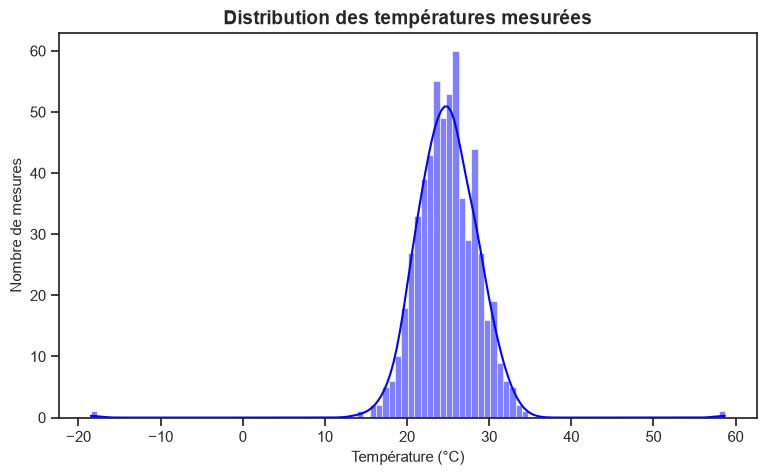

In [8]:
# Nombres de classes bins = 100

sns.set_theme(style="ticks") # thème visuel pour un rendu propre

plt.figure(figsize=(9, 5))  # l'histogramme avec la courbe de densité (KDE)
sns.histplot(data=df, x="temperature", kde=True, color="blue", bins=100)

# titres et labels
plt.title("Distribution des températures mesurées", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Nombre de mesures", fontsize=11)

plt.show()

##### 6) Affichage de la distribution des températures par bâtiment 

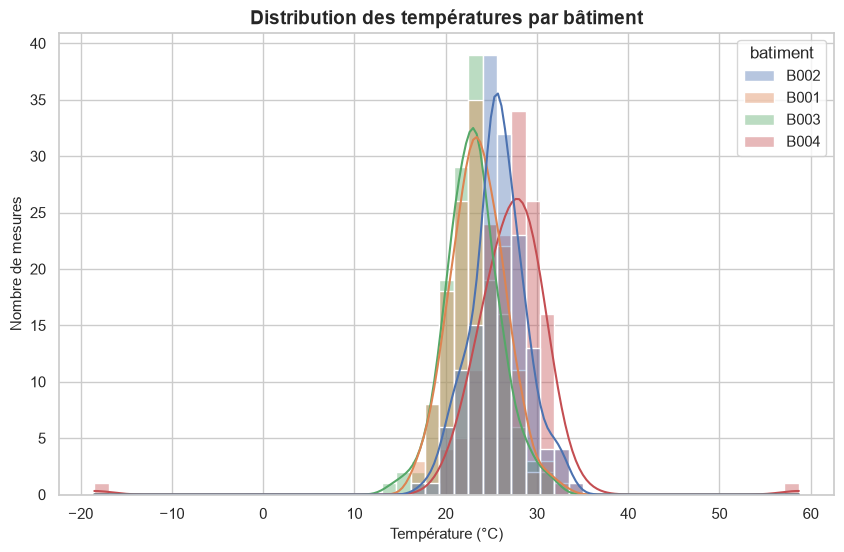

In [9]:
sns.set_theme(style="whitegrid")

# Histogramme par bâtiment
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df, 
    x="temperature", 
    hue="batiment",    # Colore et sépare les données par bâtiment
    kde=True,          # Ajoute les courbes de densité
    multiple="layer",  # Superpose les graphiques (options: "stack" ou "dodge")
    alpha=0.4          # Rend les barres transparentes pour voir les superpositions
)

plt.title("Distribution des températures par bâtiment", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Nombre de mesures", fontsize=11)

plt.show()


#### Partie 2 – Distribution d'une variable avec kdeplot() 
##### 1) Affichage de la distribution des températures 

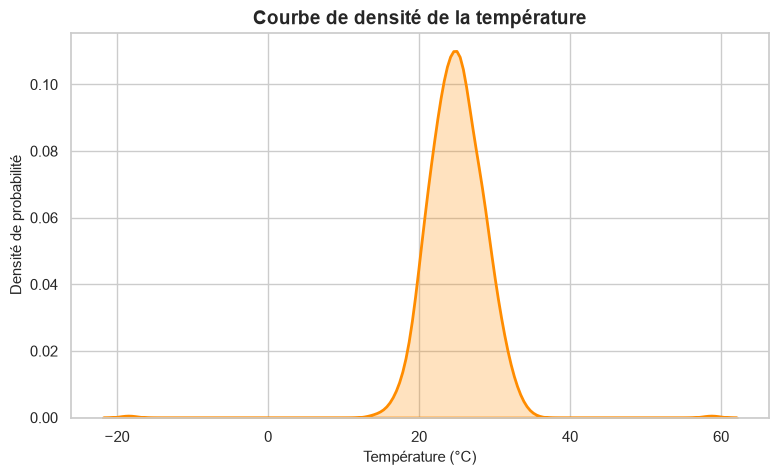

In [10]:
sns.set_theme(style="whitegrid")

# la courbe de densité (KDE)
plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df, 
    x="temperature", 
    fill=True,          # Remplit la zone sous la courbe pour une meilleure lisibilité
    color="darkorange", 
    linewidth=2         # Épaisseur de la ligne de contour
)

plt.title("Courbe de densité de la température", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Densité de probabilité", fontsize=11)

plt.show()


##### 2) Affichage de la distribution des températures par bâtiment 

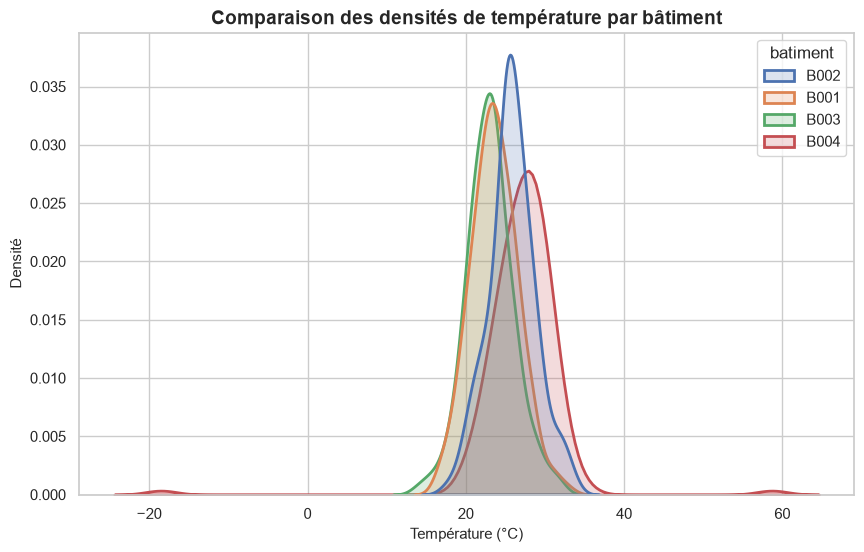

In [11]:
sns.set_theme(style="whitegrid")

# courbes de densité par bâtiment
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, 
    x="temperature", 
    hue="batiment",    # Sépare et colore les courbes par bâtiment
    fill=True,         # Remplissage transparent sous les courbes
    alpha=0.2,         # Gère l'opacité pour voir à travers les superpositions
    linewidth=2        # Épaisseur des lignes
)

plt.title("Comparaison des densités de température par bâtiment", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Densité", fontsize=11)


plt.show()


##### Partie 3 – Distribution d'une variable avec boxplot() 
##### 1) Afficher la distribution des températures 

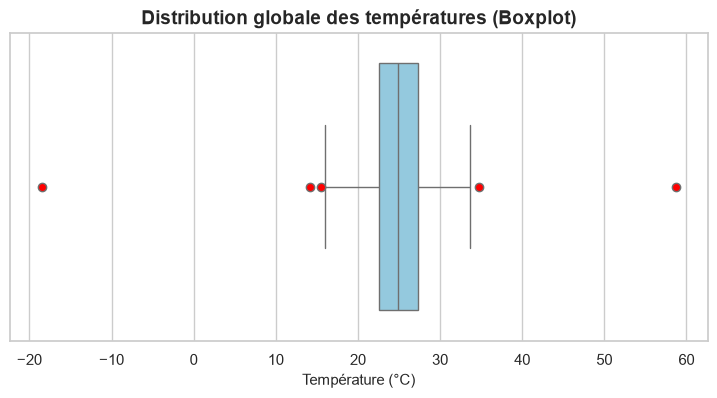

In [12]:
sns.set_theme(style="whitegrid")

# Création du boxplot (horizontal)
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=df, 
    x="temperature", 
    color="skyblue",     # Couleur de remplissage de la boîte
    flierprops={"markerfacecolor": "red", "marker": "o"} # Colore les valeurs aberrantes en rouge
)

plt.title("Distribution globale des températures (Boxplot)", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)

plt.show()


##### 2) Affichage la distribution des températures par bâtiment 

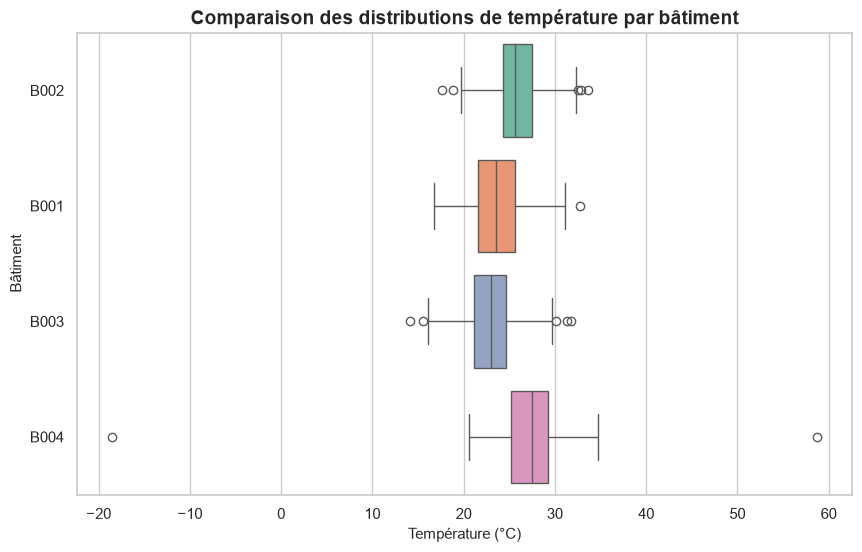

In [13]:
sns.set_theme(style="whitegrid")

# Création des boxplots par bâtiment
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x="temperature", 
    y="batiment",       # Crée une boîte distincte pour chaque bâtiment
    palette="Set2",     # Applique une palette de couleurs distinctes et modernes
    hue="batiment",     # Évite les avertissements de style dans les versions récentes
    legend=False
)

plt.title("Comparaison des distributions de température par bâtiment", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Bâtiment", fontsize=11)

plt.show()


##### 3) Pour chaque bâtiment :
        a) quelle est la médiane ? 
        b) quelle est la dispersion ?  
        c) les valeurs extrêmes 

a) La médiane d'aprés le graphe:

        batiment 'B001' : la médiane est environ 24 degrés
        batiment 'B002' : la médiane est environ 26 degrés
        batiment 'B003' : la médiane est environ 23 degrés
        batiment 'B004' : la médiane est environ 28 degrés
On peut faire un groupby pour avoir les valeurs exactes


b) quelle est la dispersion ? 

On Constate que la majorité des valeures de la température des batiments ne sont trop dispercées. Elles sont comprises entre 20 et 30 degrés

c) les valeurs extrêmes :

Pour chaque batiment on voit des valeurs extrémes de la températures représenter dans la figure par des points hors des moustaches

##### 4) quels bâtiments ont les valeurs les plus extrêmes ?  

Les valeurs les plus extemes sont -18 et 58 environ capter au niveau du batiment 'B004'

#### Partie 5 – Comptage des catégories avec countplot() 
##### 1) Affichage du nombre de mesures par état  

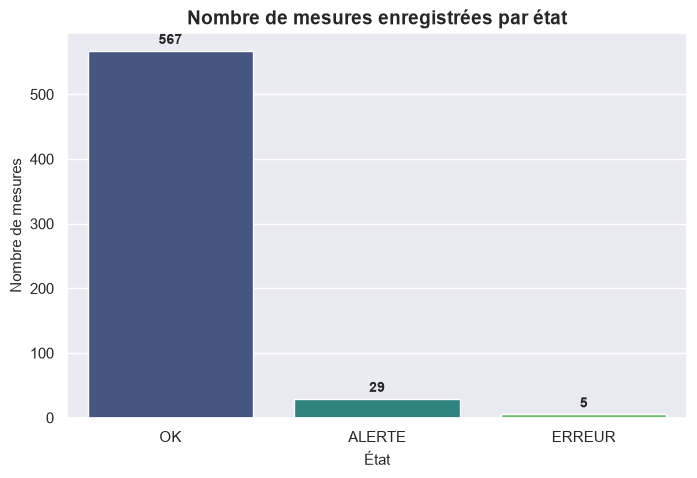

In [14]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df, 
    x="etat", 
    palette="viridis",  # Applique un dégradé de couleurs moderne
    hue="etat",         # Recommandé pour la gestion des couleurs dans Seaborn
    legend=False
)

# valeurs exactes au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold", padding=3)


plt.title("Nombre de mesures enregistrées par état", fontsize=14, fontweight="bold")
plt.xlabel("État", fontsize=11)
plt.ylabel("Nombre de mesures", fontsize=11)

plt.show()


##### 2) Affichage du nombre de mesures par bâtiment 

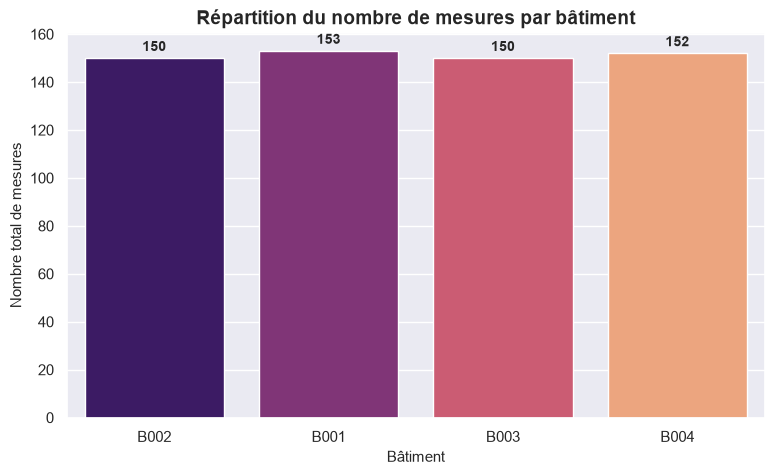

In [15]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df, 
    x="batiment", 
    palette="magma",     # Palette de couleurs chaudes (du violet au jaune)
    hue="batiment",      # Assigne une couleur unique par bâtiment
    legend=False
)

# valeurs automatiques au-dessus des barres
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold", padding=3)


plt.title("Répartition du nombre de mesures par bâtiment", fontsize=14, fontweight="bold")
plt.xlabel("Bâtiment", fontsize=11)
plt.ylabel("Nombre total de mesures", fontsize=11)

plt.show()


##### 3) Afficher les états des capteurs par bâtiment pour identifier  

        a) le bâtiment ayant le plus de mesures en état OK ; 
        b) celui ayant le plus de mesures en ALERTE ; 
        c) celui ayant le plus de mesures en ERREUR. 

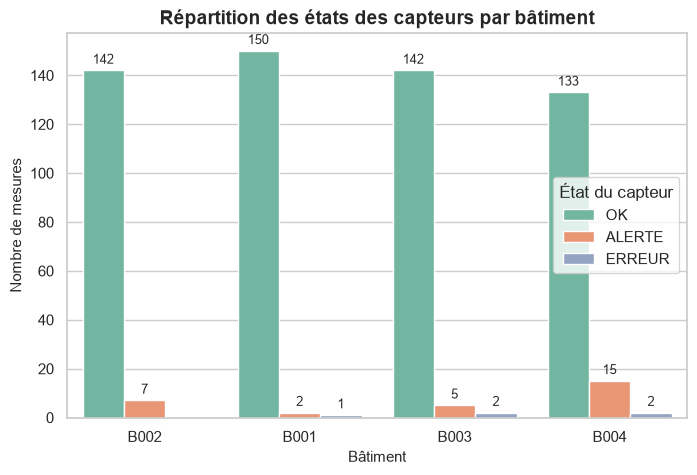

In [16]:
sns.set_theme(style="whitegrid")

# graphique de comptage croisé
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x="batiment",
    hue="etat",          # Sépare les barres de chaque bâtiment par état
    palette="Set2"       # Donne une couleur distincte à OK, ALERTE, ERREUR
)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)


plt.title("Répartition des états des capteurs par bâtiment", fontsize=14, fontweight="bold")
plt.xlabel("Bâtiment", fontsize=11)
plt.ylabel("Nombre de mesures", fontsize=11)
plt.legend(title="État du capteur")

plt.show()


#### Partie 4 – Distribution d'une variable avec violinplot() 
##### 1) Affichage de la distribution des températures 

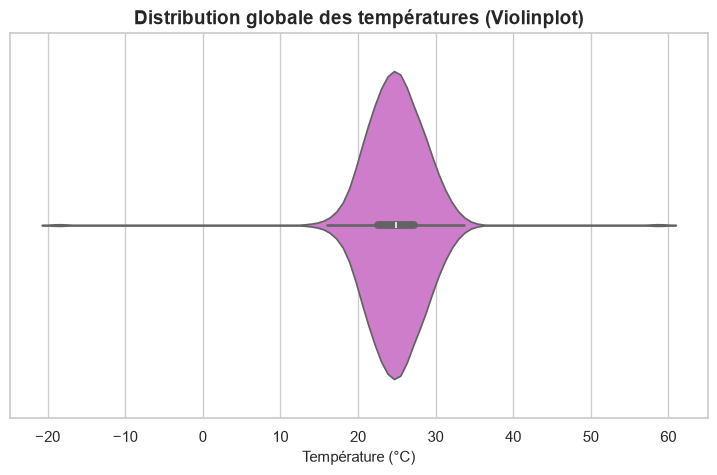

In [17]:
sns.set_theme(style="whitegrid")

# violinplot (horizontal)
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=df, 
    x="temperature", 
    color="orchid",     # Couleur de remplissage du violon
    inner="box"         # Affiche un mini-boxplot miniature à l'intérieur
)

plt.title("Distribution globale des températures (Violinplot)", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)


plt.show()

##### 2) Affichage de la distribution des températures par bâtiment 

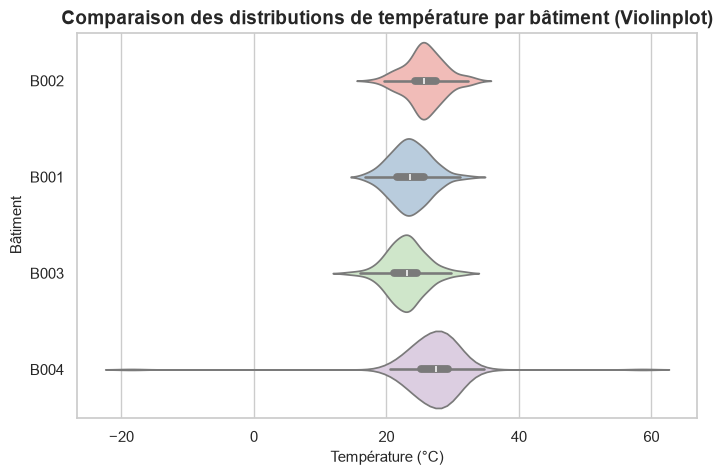

In [18]:
sns.set_theme(style="whitegrid")

# violinplots par bâtiment
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df, 
    x="temperature", 
    y="batiment",       # Crée un violon distinct par bâtiment
    palette="Pastel1",  # Applique une palette de couleurs douces
    hue="batiment",     # Évite les avertissements de style dans les versions récentes
    legend=False,
    inner="box"         # Conserve le mini-boxplot au cœur de chaque violon
)

plt.title("Comparaison des distributions de température par bâtiment (Violinplot)", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Bâtiment", fontsize=11)


plt.show()

##### 3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au boxplot ? 

le violonplot permet de visualiser en plus la bimodalité (deux pics distincts), ce que le boxplot ne nous permet pas de visualiser.

Le boxplot est excellent pour détecter rapidement les valeurs aberrantes. Le violinplot est largement supérieur pour comprendre la structure interne et les comportements cachés de nos variables.

#### Partie 6 – Relation entre deux variables avec scatterplot() 
##### 1) Etudier graphiquement la relation entre température et consommation 

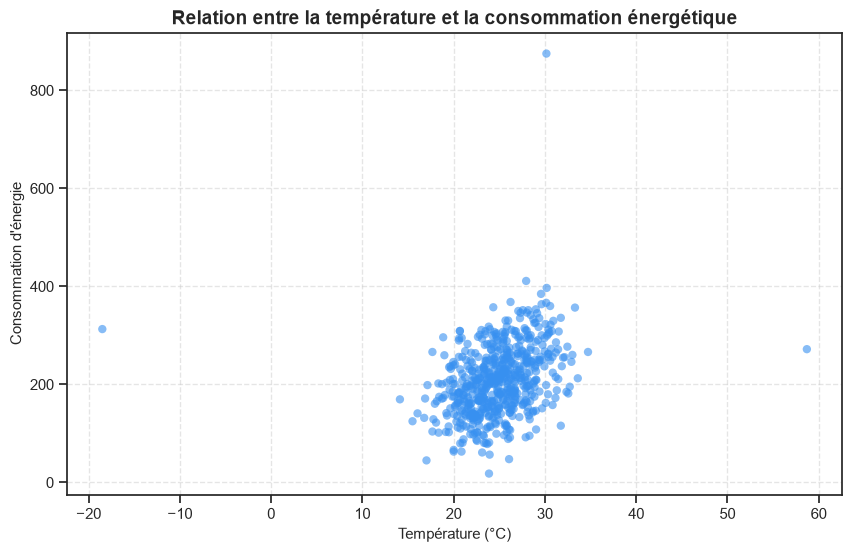

In [22]:
sns.set_theme(style="ticks")


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="temperature", 
    y="consommation", 
    alpha=0.6,          # Transparence pour mieux voir la densité en cas de superposition
    color="#3790f0",    # Couleur bleu-gris professionnelle pour les points
    edgecolor="none"    # Supprime la bordure des points pour alléger le graphique
)


plt.title("Relation entre la température et la consommation énergétique", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Consommation d'énergie", fontsize=11)


plt.grid(True, linestyle="--", alpha=0.5) # Grille légère pour faciliter la lecture des valeurs
plt.show()


##### 2) Etudions graphiquement la relation entre température et consommation par bâtiment 

Avec le nuage de point on constate on corrélation qui semble linéaire entre la température et la consommation en energie plus la température auguemente plus la consommation augmente.

##### 3) Modifier la taille des points 

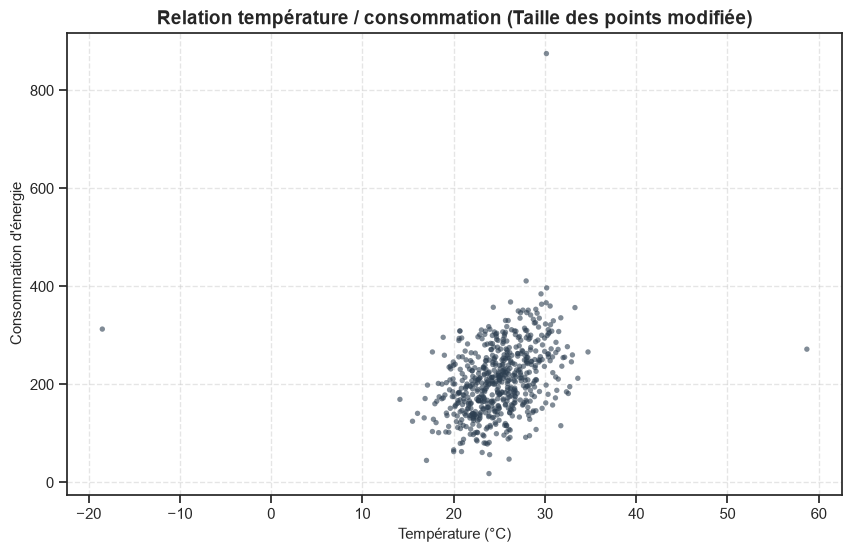

In [23]:
sns.set_theme(style="ticks")


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="temperature", 
    y="consommation", 
    s=15,               # modification de la taille des points
    alpha=0.6,          
    color="#2c3e50",    
    edgecolor="none"    
)


plt.title("Relation température / consommation (Taille des points modifiée)", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Consommation d'énergie", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### Partie 7 – Régression avec regplot() 

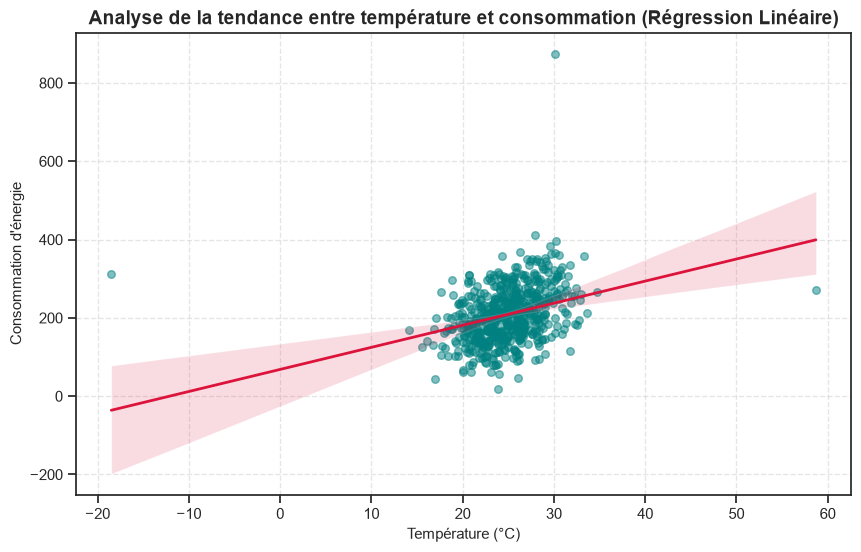

In [28]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x="temperature", 
    y="consommation",
    scatter_kws={"s": 30, "alpha": 0.5, "color": "teal"}, # Personnalise les points (taille, opacité, couleur)
    line_kws={"color": "crimson", "linewidth": 2}          # Personnalise la ligne de tendance (couleur, épaisseur)
)

plt.title("Analyse de la tendance entre température et consommation (Régression Linéaire)", fontsize=14, fontweight="bold")
plt.xlabel("Température (°C)", fontsize=11)
plt.ylabel("Consommation d'énergie", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


##### Etudions graphiquement une tendance entre température et consommation 

La pente descendante (Négative) montre que plus la température augmente, plus la consommation baisse. Cela indique généralement que la consommation est dominée par des besoins de chauffage.

la pente montante (Positive) montre que plus la température grimpe, plus la consommation augmente. Cela traduit souvent une utilisation intensive de la climatisation.

la liigne presque plate : Il n'y a pas de relation linéaire globale forte entre ces deux variables.

Largeur de la zone ombrée montre que plus la zone ombrée (l'intervalle de confiance à 95 %) est étroite, plus la tendance calculée est fiable et statistiquement solide.

##### Partie 8 – Régression avec lmplot()

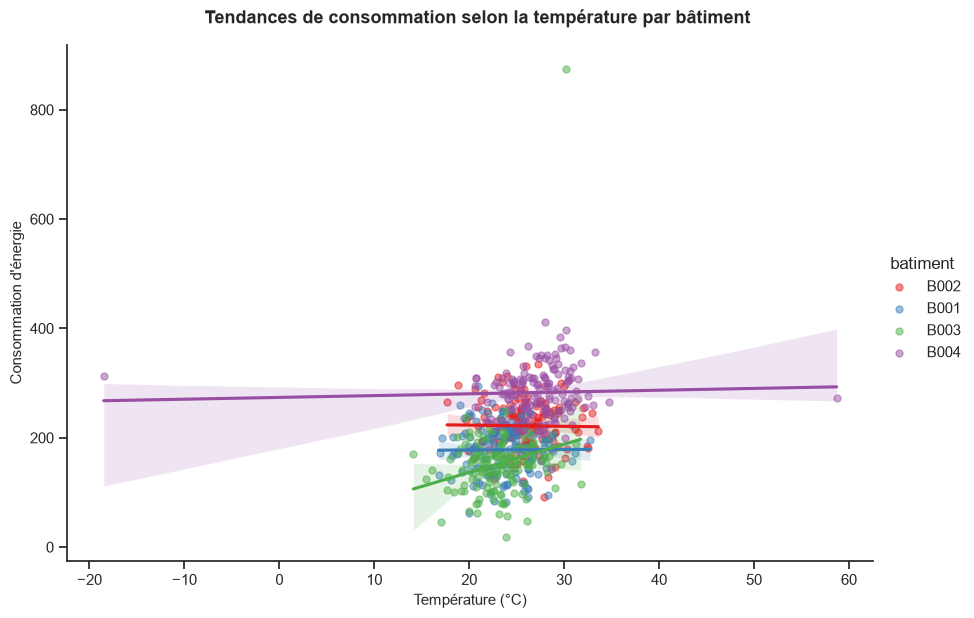

In [ ]:
sns.set_theme(style="ticks")

# Création du graphique de régression par bâtiment

g = sns.lmplot(         # lmplot gère sa propre taille via 'height' et 'aspect', pas besoin de plt.figure()
    data=df, 
    x="temperature", 
    y="consommation", 
    hue="batiment",       # Calcule et colore une régression par bâtiment
    palette="Set1",       # Palette de couleurs contrastées
    height=6,             # Hauteur du graphique
    aspect=1.5,           # Ratio largeur/hauteur
    scatter_kws={"alpha": 0.5, "s": 25} # Options pour alléger les points
)

# Habillage du graphique (titres et axes)
g.set_xlabels("Température (°C)", fontsize=11)
g.set_ylabels("Consommation d'énergie", fontsize=11)
g.fig.suptitle(
    "Tendances de consommation selon la température par bâtiment", 
    fontsize=13, 
    fontweight="bold", 
    y=1.03  # Ajuste le titre vers le haut pour ne pas chevaucher le graphique
)


plt.show()


##### Etudions graphiquement une tendance entre température et consommation par bâtiment 
Des pentes opposées entre le batiment 'B003' et les autres : le Bâtiment 3 a une pente montante qui peut etre bureaux très climatisés en été tandis que Les autres Bâtiments ont une  une pente horizontale qui semble descendante qui peut refleter un chauffage électrique sensible au froid.
, tandis que le Bâtiment 3 a une pente montante (datacenter ou bureaux très climatisés en été).

Des sensibilités différentes : la pente du bâtiment 'B004'est un peu raide, ce qui veut dire plus sa consommation est instable et sensible aux moindres variations de la météo extérieure.

#### Partie 9 – Corrélations 
##### 1) Utilisons Pandas pour calculer les corrélations entre température, humidité, pression et consommation.  

In [32]:
colonnes_cibles = ["temperature", "humidite", "pression", "consommation"] # Sélection unique des colonnes numériques demandées

matrice_corr = df[colonnes_cibles].corr()  # Calcule de la matrice de corrélation

##### 2) Affichons la matrice de corrélation obtenue avec Pandas 

In [33]:
print(matrice_corr)

              temperature  humidite  pression  consommation
temperature      1.000000 -0.006126  0.061283      0.317048
humidite        -0.006126  1.000000  0.045242     -0.046061
pression         0.061283  0.045242  1.000000      0.056051
consommation     0.317048 -0.046061  0.056051      1.000000


##### 3) Affichons le heatmap de la corrélation pour identifier : 
        a) les corrélations positives ;  
        b) les corrélations négatives ;  
        c) les corrélations proches de zéro ;  
        d) les variables qui semblent fortement liées. 

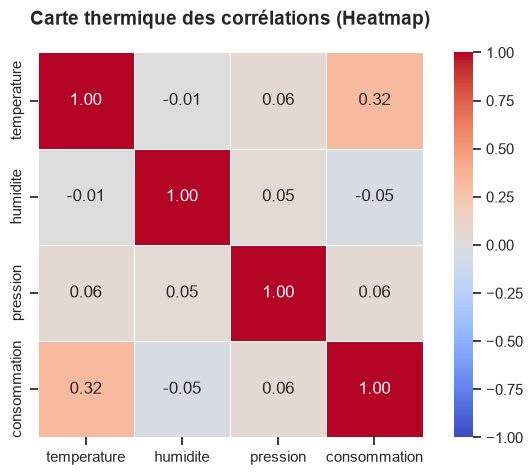

In [35]:
plt.figure(figsize=(8, 5))

# heatmap avec Seaborn
sns.heatmap(
    matrice_corr, 
    annot=True,          # Affiche les valeurs numériques dans chaque case
    cmap="coolwarm",     # Palette de couleurs divergente (Bleu = Négatif, Rouge = Positif)
    fmt=".2f",           # Arrondit les coefficients à 2 décimales
    vmin=-1, vmax=1,     # Fixe les limites de l'échelle des couleurs de -1 à 1
    linewidths=0.5,      # Ajoute une fine ligne de séparation entre les cases
    square=True          # Force les cases à être parfaitement carrées
)

plt.title("Carte thermique des corrélations (Heatmap)", fontsize=14, fontweight="bold", pad=20)

plt.show()


a) les corrélations positives : les variables consommation et températures sont corrélé positivement mais ici c'est faible.

b) les corrélations négatives : les variables (consommation, temperature) et humidité sont corrélé négativement mais ici c'est trés faible.

d) les variables qui semblent fortement liées : Les cases rouge foncé (proches de 1)  et Les cases bleu foncé (proches de -1)indiquent une forte relation directe. Mais ici il n'y a en pas 

c) les corrélations proches de zéro : Les cases claires/blanches (proches de 0) : Indiquent une absence totale de relation linéaire entre les deux variables. Ici par exemple entre 'la pression' et les autres variables

La diagonale principale : Elle affiche toujours des 1.00 en rouge foncé, car chaque variable est corrélée à 100% avec elle-même.